1. Wczytywanie pliku Parquet...
2. Przygotowanie cech (X) i celu (y)...
Ilość cech wchodzących do analizy: 468
3. Podział danych na zbiór uczący (80%) i testowy (20%)...
4. Trenowanie modelu (Random Forest)...

--- ZAKOŃCZONO TRENOWANIE ---
5. Sprawdzanie skuteczności na zbiorze testowym...

[RAPORT KLASYFIKACJI - BAGAŻ]:
                 precision    recall  f1-score   support

Brak bagażu (0)       0.98      0.72      0.83    100332
 Kupi bagaż (1)       0.11      0.67      0.19      5258

       accuracy                           0.72    105590
      macro avg       0.54      0.69      0.51    105590
   weighted avg       0.93      0.72      0.80    105590


6. Generowanie wykresu Feature Importance...


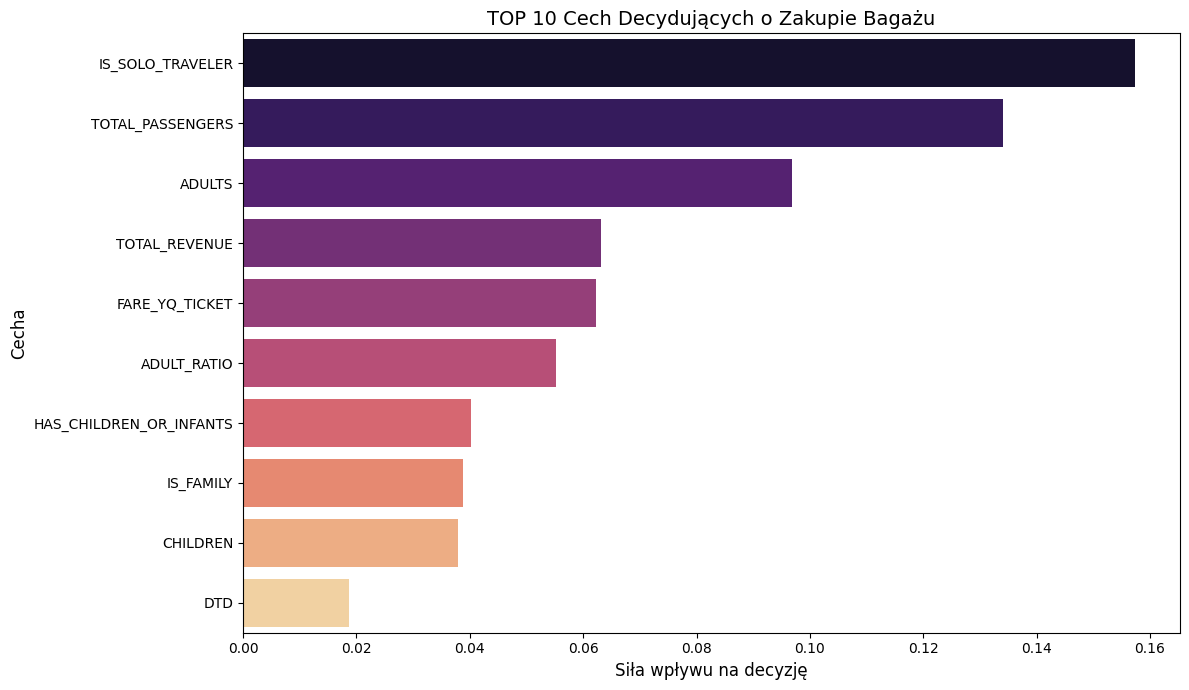

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("1. Wczytywanie pliku Parquet...")
# Ładujemy Twój docelowy plik
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

print("2. Przygotowanie cech (X) i celu (y)...")
# Nasz cel: czy pasażer kupi bagaż?
y = df_final['TARGET_BAGGAGE']

# Nasze cechy: usuwamy WSZYSTKIE kolumny z przedrostkiem TARGET_
# Model nie może wiedzieć, że ktoś kupił "Lounge", żeby łatwiej zgadnąć "Bagaż"
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

print(f"Ilość cech wchodzących do analizy: {X.shape[1]}")

print("3. Podział danych na zbiór uczący (80%) i testowy (20%)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("4. Trenowanie modelu (Random Forest)...")
# class_weight='balanced' pomaga modelowi zauważyć mniejszość (osoby kupujące bagaż)
model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("\n--- ZAKOŃCZONO TRENOWANIE ---")
print("5. Sprawdzanie skuteczności na zbiorze testowym...")
y_pred = model.predict(X_test)

print("\n[RAPORT KLASYFIKACJI - BAGAŻ]:")
print(classification_report(y_test, y_pred, target_names=['Brak bagażu (0)', 'Kupi bagaż (1)']))

print("\n6. Generowanie wykresu Feature Importance...")
# Rysowanie najważniejszych cech
importances = model.feature_importances_
fi_df = pd.DataFrame({'Cecha': X.columns, 'Ważność': importances}).sort_values(by='Ważność', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Ważność', y='Cecha', data=fi_df.head(10), palette='magma')
plt.title('TOP 10 Cech Decydujących o Zakupie Bagażu', fontsize=14)
plt.xlabel('Siła wpływu na decyzję', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.tight_layout()
plt.show()

1. Wczytywanie danych i przygotowanie...
2. Podział na zbiór uczący i testowy...
3. Uczenie XGBoost (Ciężkie działo)...
4. Analiza Prawdopodobieństw (Threshold Tuning)...

[ZMIANA REGUŁ GRY]: Model fabrycznie dawał ocenę 'Kupi' od 50% pewności.
Podnosimy poprzeczkę! Teraz model uzna zakup dopiero, gdy będzie miał ponad 80.4% pewności.

--- NOWY RAPORT KLASYFIKACJI (Z optymalizacją) ---
                 precision    recall  f1-score   support

Brak bagażu (0)       0.96      0.98      0.97    100332
 Kupi bagaż (1)       0.30      0.20      0.24      5258

       accuracy                           0.94    105590
      macro avg       0.63      0.59      0.60    105590
   weighted avg       0.93      0.94      0.93    105590



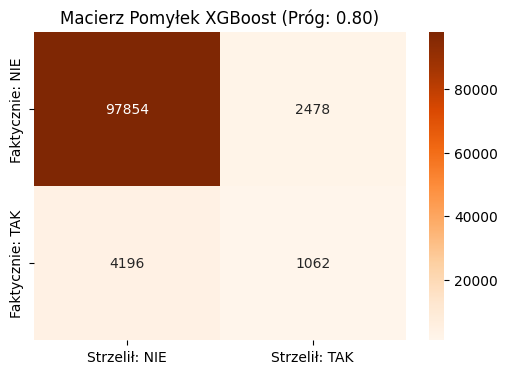

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("1. Wczytywanie danych i przygotowanie...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# Separacja cech (X) i celu (y)
y = df_final['TARGET_BAGGAGE']
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

print("2. Podział na zbiór uczący i testowy...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Uczenie XGBoost (Ciężkie działo)...")
# scale_pos_weight to odpowiednik class_weight='balanced' w XGBoost. 
# Mówi modelowi, ile razy ważniejsza jest klasa '1' (Kupi) od '0' (Nie kupi)
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Parametry zostały wstępnie dostrojone pod szybką naukę i unikanie overfittingu
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=pos_weight, 
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("4. Analiza Prawdopodobieństw (Threshold Tuning)...")
# Zamiast dawać gotowe odpowiedzi (0/1), prosimy model o prawdopodobieństwa (0.0 do 1.0)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Wyliczamy różne progi i sprawdzamy jak wpływają na Precision i Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# --- SZUKAMY OPTYMALNEGO PROGU DLA BIZNESU ---
# Załóżmy cel biznesowy: Chcemy odrzucić jak najwięcej 'śmieciowych' przewidywań, 
# więc wymagamy Precision na poziomie minimum 30%
target_precision = 0.30

# Znalezienie indeksu progu, który daje precyzję najbliższą, ale nie mniejszą niż nasz cel
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions) # Fallback jeśli cel jest nieosiągalny
    optimal_threshold = thresholds[optimal_idx]

print(f"\n[ZMIANA REGUŁ GRY]: Model fabrycznie dawał ocenę 'Kupi' od 50% pewności.")
print(f"Podnosimy poprzeczkę! Teraz model uzna zakup dopiero, gdy będzie miał ponad {optimal_threshold*100:.1f}% pewności.")

# Aplikujemy nowy, podniesiony próg decyzyjny do naszych prawdopodobieństw
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

print("\n--- NOWY RAPORT KLASYFIKACJI (Z optymalizacją) ---")
print(classification_report(y_test, y_pred_optimal, target_names=['Brak bagażu (0)', 'Kupi bagaż (1)']))

# Rysowanie Macierzy Pomyłek dla nowego progu
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimal), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Strzelił: NIE', 'Strzelił: TAK'], 
            yticklabels=['Faktycznie: NIE', 'Faktycznie: TAK'])
plt.title(f'Macierz Pomyłek XGBoost (Próg: {optimal_threshold:.2f})')
plt.show()